#### Clean Data

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
%matplotlib inline 
import matplotlib.pyplot as plt
import plotly.express as px
import sklearn

In [3]:
cd C:\Users\Lenovo\OneDrive\Desktop

C:\Users\Lenovo\OneDrive\Desktop


In [4]:
filtered_data = pd.read_csv("311data.csv")
filtered_data.shape

(800000, 29)

In [5]:
filtered_data.isnull().sum()

_id                       0
group_id                  0
num_requests              0
parent_closed             0
status_name               0
status_code               0
dept                   4103
request_type_name         0
request_type_id           0
create_date_et            0
create_date_utc           0
last_action_et            0
last_action_utc           0
closed_date_et        89049
closed_date_utc       89049
origin                    0
street               308423
cross_street         698878
street_id            301948
cross_street_id      301948
city                      0
neighborhood          36109
census_tract         218417
council_district      34677
ward                  35943
police_zone           36202
latitude              30175
longitude             30175
geo_accuracy              0
dtype: int64

### Drop Columns that are redundant (not focus of the project)

In [6]:
cleaned_data = filtered_data.drop(columns=['create_date_utc', 'last_action_utc', 'closed_date_utc', 'last_action_et',
                                           'cross_street', 'street', 'census_tract','street_id', 'cross_street_id','request_type_id'])
cleaned_data.shape

(800000, 19)

In [7]:
cleaned_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800000 entries, 0 to 799999
Data columns (total 19 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   _id                800000 non-null  int64  
 1   group_id           800000 non-null  int64  
 2   num_requests       800000 non-null  int64  
 3   parent_closed      800000 non-null  object 
 4   status_name        800000 non-null  object 
 5   status_code        800000 non-null  int64  
 6   dept               795897 non-null  object 
 7   request_type_name  800000 non-null  object 
 8   create_date_et     800000 non-null  object 
 9   closed_date_et     710951 non-null  object 
 10  origin             800000 non-null  object 
 11  city               800000 non-null  object 
 12  neighborhood       763891 non-null  object 
 13  council_district   765323 non-null  float64
 14  ward               764057 non-null  float64
 15  police_zone        763798 non-null  float64
 16  la

In [8]:
cleaned_data.isnull().sum()

_id                      0
group_id                 0
num_requests             0
parent_closed            0
status_name              0
status_code              0
dept                  4103
request_type_name        0
create_date_et           0
closed_date_et       89049
origin                   0
city                     0
neighborhood         36109
council_district     34677
ward                 35943
police_zone          36202
latitude             30175
longitude            30175
geo_accuracy             0
dtype: int64

### Converting to datetime format

In [9]:
# Convert date columns to DateTime format
cleaned_data['create_date_et'] = pd.to_datetime(cleaned_data['create_date_et'], errors='coerce')
cleaned_data['closed_date_et'] = pd.to_datetime(cleaned_data['closed_date_et'], errors='coerce')

### Filling in missing values 
#### neighborhood

In [10]:
# Fill in missing neighborhoods using latitude and longitude
missing_values_count = cleaned_data['neighborhood'].isna().sum()
print(f" Initial Missing values in neighborhood: {missing_values_count}")

# Reverse geocoding function
def get_neighborhood(lat, lon):
    try:
        location = geolocator.reverse(f"{lat}, {lon}", exactly_one=True)
        return location.raw['address'].get('neighbourhood', 'Unknown')
    except:
        return 'Unknown'

#Execute only on data that lacks neighborhood and has longitude and latitude
mask = cleaned_data['neighborhood'].isna() & cleaned_data['latitude'].notna() & cleaned_data['longitude'].notna()
cleaned_data.loc[mask, 'neighborhood'] = cleaned_data[mask].apply(
    lambda row: get_neighborhood(row['latitude'], row['longitude']), axis=1
)

missing_values_count = cleaned_data['neighborhood'].isna().sum()
print(f"Missing values in neighborhood: {missing_values_count}")

 Initial Missing values in neighborhood: 36109
Missing values in neighborhood: 30155


In [11]:
# Checking proportion of neighborhoods missing 
missing_neighborhoods = cleaned_data[cleaned_data['neighborhood'] == 'Unknown']
missing_neighborhoods_count = len(missing_neighborhoods)
total_count = len(cleaned_data)
missing_neighborhoods_proportion = missing_neighborhoods_count / total_count * 100
print(f"Proportion of neighborhoods missing: {missing_neighborhoods_proportion:.2f}%")

Proportion of neighborhoods missing: 0.74%


In [12]:
# Drop rows with missing values in 'neighborhood' and 'Unknown'
# Drop rows with missing values in 'neighborhood'
cleaned_data = cleaned_data[cleaned_data['neighborhood'] != 'Unknown']

# Drop rows with missing values in 'neighborhood'
cleaned_data = cleaned_data.dropna(subset=['neighborhood'])

missing_values_count = cleaned_data['neighborhood'].isna().sum()
print(f"Missing values in neighborhood: {missing_values_count}")

Missing values in neighborhood: 0


#### police_zone

In [13]:
# Fill in missing value for police_zone
# Fill values based on https://pghsafeneighborhoods.wordpress.com/wp-content/uploads/2008/06/zones-by-neighborhood.pdf

# Neighborhoods without police zone
unique_neighborhoods = cleaned_data.loc[cleaned_data['police_zone'].isna(), 'neighborhood'].unique()
print(unique_neighborhoods)

# Fill in missing values for police_zone
dict_neighborhoods_policezone = {'Windgap': 6.0, 
                                 'Overbrook': 3.0,
                                 'Mount Oliver Borough': 3.9,
                                 'Mt. Oliver': 3.0,
                                 'Swisshelm Park': 4.0,
                                 'Westwood': 6.0,
                                 'Banksville': 3.0,
                                 'Fairywood': 6.0,
                                 'Knoxville': 3.0,
                                 'Ridgemont': 3.0,
                                 'East Carnegie': 6.0,
                                 'Oakwood': 6.0
}

for neighborhood, police_zone in dict_neighborhoods_policezone.items():
    cleaned_data.loc[cleaned_data['neighborhood'] == neighborhood, 'police_zone'] = police_zone

# Check if there are still missing values
missing_values_count = cleaned_data['police_zone'].isna().sum()
print(f"Missing values in police_zone: {missing_values_count}")

['Mount Oliver Borough' 'Windgap' 'Overbrook' 'Mt. Oliver'
 'Swisshelm Park' 'Oakwood' 'Westwood' 'Brookline' 'Ridgemont' 'Fairywood'
 'Banksville' 'Carrick' 'Knoxville' 'East Carnegie']
Missing values in police_zone: 2


In [14]:
# Drop rows with missing values in 'police_zone'
cleaned_data = cleaned_data.dropna(subset=['police_zone'])
cleaned_data = cleaned_data[cleaned_data['police_zone'] != 0]


In [15]:
# Check if there are still missing values
missing_values_count = cleaned_data['police_zone'].isna().sum() + (cleaned_data['police_zone'] == 0).sum()
print(f"Missing values in police_zone: {missing_values_count}")

Missing values in police_zone: 0


#### council

In [16]:
# Fill in Council District
cleaned_data['council_district'].unique()

mapping = {
    "Knoxville": 3,
    "Regent Square": 5,
    "Carrick": 4,
    "Fairywood": 2,
    "Oakwood": 2,
    "Lincoln Place": 5,
    "Brookline": 4,
    "East Hills": 9,
    "Westwood": 2,
    "Point Breeze": 8,
    "Homewood South": 9,
    "Overbrook": 4,
    "Spring Garden": 1,
    "Beechview": 4,
    "Perry North": 1,
    "Point Breeze North": 8,
    "Squirrel Hill North": 8,
    "Arlington": 3,
    "East Carnegie": 2,
    "East Liberty": 9,
    "North Oakland": 8,
    "Strip District": 7,
    "Summer Hill": 1,
    "Mount Oliver Borough": 11,}

missing_mask = cleaned_data['council_district'].isna()

cleaned_data.loc[missing_mask, 'council_district'] = cleaned_data.loc[missing_mask, 'neighborhood'].map(mapping)

missing_values_count = cleaned_data['council_district'].isna().sum()
print(f"Missing values in council_district: {missing_values_count}")


Missing values in council_district: 0


#### department

In [17]:
# Fill in missing departments using codebook (from 311Codebook.csv)

codebook = pd.read_csv("311 Codebook Request Types - Codebook.csv")

# Create a mapping dictionary for Issue and Department
issue_dept_mapping = codebook.set_index('Issue')['Department'].to_dict()

# Fill missing departments in cleaned_data using the mapping
cleaned_data['dept'] = cleaned_data.apply(
    lambda row: issue_dept_mapping[row['request_type_name']] if pd.isna(row['dept']) and row['request_type_name'] in issue_dept_mapping else row['dept'],
    axis=1
)

# Remaining missing rows fall under the category 'In database, but not on 311 Web Submission Form'

In [18]:
# Check neighborhoods with missing departments as a proportion of the total requests in the neighborhood
neighborhood_counts = cleaned_data['neighborhood'].value_counts()
neighborhood_counts = neighborhood_counts[neighborhood_counts > 0]

# Calculate the proportion of missing departments for each neighborhood
proportion_missing_dept = cleaned_data[cleaned_data['dept'].isna()]['neighborhood'].value_counts() / neighborhood_counts
proportion_missing_dept = proportion_missing_dept[proportion_missing_dept > 0]

# Sort the neighborhoods by proportion of missing departments
proportion_missing_dept = proportion_missing_dept.sort_values(ascending=False)

proportion_missing_dept

neighborhood
Crawford-Roberts     0.028875
Middle Hill          0.024030
Crafton Heights      0.019164
North Oakland        0.017091
East Carnegie        0.016575
                       ...   
Oakwood              0.001294
Ridgemont            0.001116
Chartiers City       0.000899
South Side Slopes    0.000694
Bon Air              0.000439
Name: count, Length: 88, dtype: float64

In [19]:
# Since the missing departments are not significant, we can drop the rows with missing departments
cleaned_data = cleaned_data.dropna(subset=['dept'])

In [20]:
cleaned_data.isnull().sum()

_id                      0
group_id                 0
num_requests             0
parent_closed            0
status_name              0
status_code              0
dept                     0
request_type_name        0
create_date_et           0
closed_date_et       83262
origin                   0
city                     0
neighborhood             0
council_district         0
ward                    54
police_zone              0
latitude                19
longitude               19
geo_accuracy             0
dtype: int64

### Create Columns
#### dept → category

In [21]:
# Create a new column called Category for request types using the codebook

# Create a mapping dictionary for Issue and Category
issue_category_mapping = codebook.set_index('Issue')['Category'].to_dict()

# Create new columns called category and input values based on the mapping
cleaned_data['category'] = cleaned_data.apply(
    lambda row: issue_category_mapping[row['request_type_name']] if row['request_type_name'] in issue_category_mapping else row['request_type_name'],
    axis=1
)

# Check if there are still missing values
missing_values_count = cleaned_data['category'].isna().sum()
missing_values_count

0

In [22]:
# Simplify the Department names
cleaned_data['dept_simplified'] = cleaned_data['dept'].str.split(' - ').str[0]
cleaned_data['dept_simplified'].unique()

dept_counts = cleaned_data['dept_simplified'].value_counts()
dept_counts

dept_simplified
DPW                                     309146
Permits, Licenses and Inspections       164443
DOMI                                    102289
Police                                   78112
Pittsburgh Water and Sewer Authority     29493
Animal Care & Control                    22611
Finance                                  12227
Allegheny City Electric                  11115
Sargent Electric                          6532
311                                       5835
Fire Bureau                               2487
Parking Authority                         2395
Public Safety                             2239
City Planning                             1660
OMI                                       1640
ACHD                                      1521
SPIN Scooters                             1246
Mayor's Office                             852
911                                        815
Commission on Human Relations              539
Port Authority Transit                     5

### Dropping rows/columns

In [23]:
cleaned_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 760313 entries, 96 to 799999
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   _id                760313 non-null  int64         
 1   group_id           760313 non-null  int64         
 2   num_requests       760313 non-null  int64         
 3   parent_closed      760313 non-null  object        
 4   status_name        760313 non-null  object        
 5   status_code        760313 non-null  int64         
 6   dept               760313 non-null  object        
 7   request_type_name  760313 non-null  object        
 8   create_date_et     760313 non-null  datetime64[ns]
 9   closed_date_et     677051 non-null  datetime64[ns]
 10  origin             760313 non-null  object        
 11  city               760313 non-null  object        
 12  neighborhood       760313 non-null  object        
 13  council_district   760313 non-null  float64     

In [24]:
cleaned_data.isnull().sum()

_id                      0
group_id                 0
num_requests             0
parent_closed            0
status_name              0
status_code              0
dept                     0
request_type_name        0
create_date_et           0
closed_date_et       83262
origin                   0
city                     0
neighborhood             0
council_district         0
ward                    54
police_zone              0
latitude                19
longitude               19
geo_accuracy             0
category                 0
dept_simplified          0
dtype: int64

3# Dropping rows with missing census_tract values since it is hard to impute and there are too many missing
cleaned_data = cleaned_data.drop(columns=['census_tract', 'latitude', 'longitude'])

In [25]:
# Dropping rows with missing wards because they are not directly related to neighborhoods

# Show the proportion of missing wards in the dataset (NaNs and 0s represent missing wards)
missing_wards_count = cleaned_data['ward'].isna().sum() + (cleaned_data['ward'] == 0).sum()
total_count = len(cleaned_data)
missing_wards_proportion = missing_wards_count / total_count * 100
print(f"Proportion of missing wards: {missing_wards_proportion:.2f}%")

# Drop rows with missing values in 'ward'
cleaned_data = cleaned_data.dropna(subset=['ward'])
cleaned_data = cleaned_data[cleaned_data['ward'] != 0]

# Check if there are still missing values
missing_values_count = cleaned_data['ward'].isna().sum() + (cleaned_data['ward'] == 0).sum()
print(f"Missing values in ward: {missing_values_count}")

Proportion of missing wards: 0.03%
Missing values in ward: 0


In [26]:
# Removing rows with '(DO NOT USE)' in request_type_name
cleaned_data = cleaned_data[~cleaned_data['request_type_name'].str.contains(r'\(DO NOT USE\)', case=False, na=False)]

In [27]:
# Dropping request_type_name and using Category instead
cleaned_data = cleaned_data.drop(columns=['request_type_name'])

# Dropping dept and using dept_simplified instead
cleaned_data = cleaned_data.drop(columns=['dept'])

In [28]:
cleaned_data = cleaned_data.dropna(subset=['latitude'])
cleaned_data = cleaned_data.dropna(subset=['longitude'])

In [29]:
cleaned_data.isnull().sum()

_id                     0
group_id                0
num_requests            0
parent_closed           0
status_name             0
status_code             0
create_date_et          0
closed_date_et      83196
origin                  0
city                    0
neighborhood            0
council_district        0
ward                    0
police_zone             0
latitude                0
longitude               0
geo_accuracy            0
category                0
dept_simplified         0
dtype: int64

In [30]:
cleaned_data.shape

(759654, 19)

### Adding Demographic Data

In [31]:
# Read in neighborhood data
neighborhoods = pd.read_csv('2020Census_Neighborhood_Dataset.csv')

In [32]:
# Removing columns from 2010 and that are comparisons between 2020 and 2010
to_drop = neighborhoods.columns[neighborhoods.columns.str.startswith(('2010', 'Change'))]
neighborhoods.drop(to_drop, axis=1, inplace=True)

In [33]:
# Changing Neighborhood column capitalization to make merging easier
neighborhoods = neighborhoods.rename(columns = {'Neighborhood': 'neighborhood'})

# Dropping _id column
neighborhoods.drop('_id', axis=1, inplace=True)

In [34]:
neighborhoods

,neighborhood,2020_Total_Population,2020_OneRace_Population,2020_White_Alone_Population,2020_Black_Alone_Population,2020_American_Indian_and_Alaska_Native_alone_population,2020_Asian_Alone_Population,2020_Native_Hawaiian_and_Other_Pacific_Islander_alone_Populatio,2020_Any_other_single_race_alone_Popualtion,2020_Population_two_or_more_races,2020_Hispanic_or_Latino_Population
0,Allegheny Center,1419,1337,683,390,8,235,1,20,82,50
1,Allegheny West,540,493,426,32,1,16,1,17,47,41
2,Allentown,2305,2126,1272,785,3,19,6,41,179,81
3,Arlington - Arlington Heights (Combined),2040,1889,1206,620,5,12,0,46,151,68
4,Banksville,4127,3856,3191,194,7,385,2,77,271,158
...,...,...,...,...,...,...,...,...,...,...,...
84,Upper Lawrenceville,2394,2266,2018,154,5,74,0,15,128,66
85,West End,205,180,118,50,1,6,2,3,25,11
86,West Oakland,2534,2455,1532,608,6,197,2,110,79,112
87,Westwood,3332,3147,2196,278,3,592,2,76,185,122


In [35]:
# Changing each neighborhood's race columns to proportions of the neighborhood's population

# Applying to all columns except 'neighborhood' and '2020_Total_Population'
neighborhoods.iloc[:, 2:].astype('float64')
neighborhoods.iloc[:, 2:] = neighborhoods.iloc[:, 2:].div(neighborhoods['2020_Total_Population'], axis=0);

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_25520\240816995.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0     0.942213
1     0.912963
2     0.922343
3     0.925980
4     0.934335
        ...   
84    0.946533
85    0.878049
86    0.968824
87    0.944478
88    0.936012
Name: 2020_OneRace_Population, Length: 89, dtype: float64' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  neighborhoods.iloc[:, 2:] = neighborhoods.iloc[:, 2:].div(neighborhoods['2020_Total_Population'], axis=0);
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_25520\240816995.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0     0.481325
1     0.788889
2     0.551844
3     0.591176
4     0.773201
        ...   
84    0.842941
85    0.575610
86    0.604578
87    0.659064
88    0.530506
Name: 2020_White_Alone_Population, Length: 89

In [36]:
# Changes in dataset -> census data

# Central Business District -> Central Business District (Downtown)
# Spring Hill-City View -> 	Spring Hill-City
# Mount Oliver Borough -> Mt. Oliver
# Arlington -> Arlington - Arlington Heights (Combined)
# Arlington Heights -> 	Arlington - Arlington Heights (Combined)

recode_nbhds = {'Central Business District': 'Central Business District (Downtown)', 'Spring Hill-City View': 'Spring Hill-City',
                'Mount Oliver Borough': 'Mt. Oliver', 'Arlington': 'Arlington - Arlington Heights (Combined)',
                'Arlington Heights': 'Arlington - Arlington Heights (Combined)'}

# Making changes to original DataFrame to combine neighborhood data
cleaned_data['neighborhood'] = cleaned_data['neighborhood'].replace(recode_nbhds)

In [37]:
# Merging both DataFrames on neighborhood columns
cleaned_data = pd.merge(cleaned_data, neighborhoods, how = 'left', on = 'neighborhood')

In [38]:
cleaned_data.columns

Index(['_id', 'group_id', 'num_requests', 'parent_closed', 'status_name',
       'status_code', 'create_date_et', 'closed_date_et', 'origin', 'city',
       'neighborhood', 'council_district', 'ward', 'police_zone', 'latitude',
       'longitude', 'geo_accuracy', 'category', 'dept_simplified',
       '2020_Total_Population', '2020_OneRace_Population',
       '2020_White_Alone_Population', '2020_Black_Alone_Population',
       '2020_American_Indian_and_Alaska_Native_alone_population',
       '2020_Asian_Alone_Population',
       '2020_Native_Hawaiian_and_Other_Pacific_Islander_alone_Populatio',
       '2020_Any_other_single_race_alone_Popualtion',
       '2020_Population_two_or_more_races',
       '2020_Hispanic_or_Latino_Population'],
      dtype='object')

In [39]:
cleaned_data['parent_closed'] = cleaned_data['parent_closed'].replace({'t': 1, 'f': 0})

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_25520\2794220475.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cleaned_data['parent_closed'] = cleaned_data['parent_closed'].replace({'t': 1, 'f': 0})


cleaned_data = cleaned_data.drop(columns=['_id','group_id'])

In [40]:
cleaned_data.nunique(axis=0)

_id                                                                759654
group_id                                                           759654
num_requests                                                           40
parent_closed                                                           2
status_name                                                             4
status_code                                                             4
create_date_et                                                     603103
closed_date_et                                                     393133
origin                                                                 10
city                                                                   24
neighborhood                                                           89
council_district                                                        9
ward                                                                   32
police_zone                           

cleaned_data = cleaned_data.drop(columns=['status_name','parent_closed','status_code'])

In [42]:
data_recent =cleaned_data.sort_values('create_date_et')

In [43]:
data_recent['create_date_et']

128651   2015-04-20 07:37:00
171952   2015-04-20 07:40:00
90446    2015-04-20 07:41:00
385404   2015-04-20 07:46:00
385633   2015-04-20 07:47:00
                 ...        
759651   2024-12-18 09:28:00
759648   2024-12-18 09:32:00
759647   2024-12-18 09:39:00
759644   2024-12-18 09:40:00
759653   2024-12-18 09:41:00
Name: create_date_et, Length: 759654, dtype: datetime64[ns]

In [44]:
recent_mask = data_recent['create_date_et'].dt.year >= 2021
X_recent = data_recent.loc[recent_mask, :]

In [45]:
X_recent['create_date_et']

406945   2021-01-01 03:26:00
265555   2021-01-01 06:17:00
326559   2021-01-01 06:20:00
237711   2021-01-01 10:34:00
414644   2021-01-01 10:47:00
                 ...        
759651   2024-12-18 09:28:00
759648   2024-12-18 09:32:00
759647   2024-12-18 09:39:00
759644   2024-12-18 09:40:00
759653   2024-12-18 09:41:00
Name: create_date_et, Length: 348812, dtype: datetime64[ns]

In [46]:
X_recent.nunique(axis=0)

_id                                                                348812
group_id                                                           348812
num_requests                                                           30
parent_closed                                                           2
status_name                                                             4
status_code                                                             4
create_date_et                                                     272940
closed_date_et                                                     159128
origin                                                                  9
city                                                                   23
neighborhood                                                           89
council_district                                                        9
ward                                                                   32
police_zone                           

cleaned_data_encoded = pd.get_dummies(X_recent, sparse=True)

cleaned_data_encoded.shape

cleaned_data_encoded['create_date_et']

In [47]:
closed_requests =X_recent[X_recent['closed_date_et'].notna()].copy()
open_requests = X_recent[X_recent['closed_date_et'].isna()].copy()

In [51]:
print(closed_requests.shape,closed_requests.shape[0]/X_recent.shape[0])
print(open_requests.shape,open_requests.shape[0]/X_recent.shape[0])

(300510, 29) 0.8615242594864856
(48302, 29) 0.13847574051351444


## i. Non-closed request

In [53]:
status_dist = open_requests['status_name'].value_counts(normalize=True).mul(100).round(2)
print(f"status distribution（%）:\n{status_dist.to_string()}")

status distribution（%）:
status_name
open           57.92
in progress    41.34
on hold         0.75


In [63]:
for status in ['open', 'in progress', 'on hold']:
    status_subset = open_requests[open_requests['status_name'] == status]
    top_types = status_subset['category'].value_counts().head(10)
    print(f"\n{status}: top 10 request types")
    print(top_types.to_string())


open: top 10 request types
category
Parking                                            6353
Road/Street Issues                                 2723
Public Safety                                      2398
Dashcam                                            1749
In database, but not on 311 Web Submission Form    1186
SPIN (Stand Up) Scooters                           1102
City Owned Property Maintenance                     930
Neighborhood Issues                                 906
Utility Issues                                      736
Parks Issues                                        680

in progress: top 10 request types
category
Neighborhood Issues                                5353
Parking                                            1805
Road/Street Issues                                 1767
Building Maintenance                               1739
Tree Issues                                        1129
Public Safety                                       974
Construction Issues    

## closed request

In [56]:
closed_top = closed_requests['category'].value_counts().head(10)
print(f"closed requests top 10:\n{closed_top.to_string()}")

closed requests top 10:
category
Road/Street Issues           60088
Neighborhood Issues          41309
Missed Refuse Pick Up        27100
Parking                      17216
Missed Recycling Pick Up     13290
Refuse Violations            12181
Garbage and Litter Issues    11428
Building Maintenance         11245
Animal Issues                 9800
Street Light                  8870


In [58]:
closed_requests['time_taken'] = (closed_requests['closed_date_et'] - closed_requests['create_date_et']).dt.total_seconds() / 3600 /24
closed_requests['time_taken']

406945      4.383333
265555      5.346528
326559    221.123611
237711      2.936111
414644      3.848611
             ...    
759649      2.082639
759651      0.010417
759648      0.749306
759647      2.215278
759653     83.960417
Name: time_taken, Length: 300510, dtype: float64

In [66]:
closed_requests['create_hour'] = closed_requests['create_date_et'].dt.hour
closed_requests['create_month'] = closed_requests['create_date_et'].dt.month

In [67]:
import holidays
us_holidays = holidays.US(years=closed_requests['create_date_et'].dt.year.unique())
closed_requests['is_holiday'] = closed_requests['create_date_et'].apply(lambda x: x in us_holidays).astype(int)

In [62]:
time_stats = closed_requests.groupby('category')['time_taken'].agg(
    ['count', 'mean', 'median', 'min', 'max', 'std']
).sort_values('mean', ascending=False)

print("\nTop 10 requests with the longest average processing time:")
print(time_stats.head(10).to_string())

print("\n10 requests with the shortest average processing time:")
print(time_stats[time_stats['count'] > 50].tail(10).to_string()) 

long_requests = closed_requests[closed_requests['time_taken'] > 30]  
print(f"\n# of requests processed over 30 days: {len(long_requests)}")
print("distribution of these requests:")
print(long_requests['category'].value_counts().head(10).to_string())


Top 10 requests with the longest average processing time:
                          count         mean       median          min          max         std
category                                                                                       
County Maintenance            1  1281.039583  1281.039583  1281.039583  1281.039583         NaN
Thank you - DPW               1  1226.086806  1226.086806  1226.086806  1226.086806         NaN
Water Runoff in ROW         109   586.700357   505.052083     0.000000  1192.269444  378.484081
Crashes and Close Calls     132   399.301436   470.072222     0.000000   978.757639  264.346430
Ballfield                    22   355.510417   405.953125     0.979861   546.051389  169.225448
Repair City Steps           235   353.715086   186.995139     0.000000  1379.998611  380.672476
Traffic Signals Surtrac       2   321.372222   321.372222     0.002083   642.742361  454.486009
SPIN (Stand Up) Scooters    135   297.561111   303.034722     0.000000   570.

In [60]:
type_counts2 = closed_requests['category'].value_counts(normalize=True)
# Top 20 High frequency types
type_counts2.head(20)

category
Road/Street Issues                                 0.199953
Neighborhood Issues                                0.137463
Missed Refuse Pick Up                              0.090180
Parking                                            0.057289
Missed Recycling Pick Up                           0.044225
Refuse Violations                                  0.040534
Garbage and Litter Issues                          0.038029
Building Maintenance                               0.037420
Animal Issues                                      0.032611
Street Light                                       0.029516
Tree Issues                                        0.025956
Litter, Public Property                            0.025646
Public Safety                                      0.024615
Construction Issues                                0.023640
Utility Issues                                     0.022072
Blue Bin Containers                                0.018199
Traffic and Street Sign Issues 

In [64]:
# Neighborhood-level resolution time analysis
neighborhood_times = closed_requests.groupby('neighborhood')['time_taken'].agg(['mean', 'count'])
neighborhood_demo = closed_requests[['neighborhood', '2020_Black_Alone_Population']].drop_duplicates()

# Merge with demographic data
geo_bias = pd.merge(neighborhood_times, neighborhood_demo, on='neighborhood')
geo_bias['black_pop_quartile'] = pd.qcut(geo_bias['2020_Black_Alone_Population'], 4)

# Compare resolution times across population groups
print(geo_bias.groupby('black_pop_quartile')['mean'].describe())

                    count       mean        std        min        25%  \
black_pop_quartile                                                      
(0.0258, 0.0712]     23.0  48.068440  12.825214  25.624678  37.621473   
(0.0712, 0.232]      22.0  43.641047  13.107663  23.219641  37.427711   
(0.232, 0.456]       22.0  46.690122  11.972553  19.159657  39.890397   
(0.456, 0.922]       22.0  48.325724  11.674231  26.097753  43.695662   

                          50%        75%        max  
black_pop_quartile                                   
(0.0258, 0.0712]    45.832707  58.198170  68.475755  
(0.0712, 0.232]     40.350509  46.362095  89.579846  
(0.232, 0.456]      44.953304  53.847013  72.044738  
(0.456, 0.922]      46.302603  52.105621  75.241589  


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_25520\554997758.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(geo_bias.groupby('black_pop_quartile')['mean'].describe())


In [69]:
# Resolution time vs. request submission hour
closed_requests['create_hour'] = closed_requests['create_date_et'].dt.hour
time_bias = closed_requests.groupby('create_hour')['time_taken'].mean()

# Holiday vs. non-holiday comparison
holiday_mask = closed_requests['create_date_et'].isin(us_holidays)
holiday_times = closed_requests[holiday_mask]['time_taken'].mean()
non_holiday_times = closed_requests[~holiday_mask]['time_taken'].mean()
print(holiday_times)
print(non_holiday_times)

27.61875
46.7242506046243


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_25520\1584988386.py:6: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  holiday_mask = closed_requests['create_date_et'].isin(us_holidays)


In [72]:
holiday_types = closed_requests[holiday_mask]['category'].value_counts(normalize=True)
non_holiday_types = closed_requests[~holiday_mask]['category'].value_counts(normalize=True)
print("holiday_types:\n", holiday_types.head(5))
print("\nnon_holiday_types:\n", non_holiday_types.head(5))

holiday_types:
 category
Public Safety         0.5
Road/Street Issues    0.5
Name: proportion, dtype: float64

non_holiday_types:
 category
Road/Street Issues          0.199951
Neighborhood Issues         0.137464
Missed Refuse Pick Up       0.090181
Parking                     0.057290
Missed Recycling Pick Up    0.044225
Name: proportion, dtype: float64


In [75]:
origin_analysis = closed_requests.groupby('origin').agg(
    avg_time=('time_taken', 'mean'),
    resolution_rate=('status_name', lambda x: (x == 'closed').mean()),
    count=('origin', 'count')
).sort_values('avg_time', ascending=False)


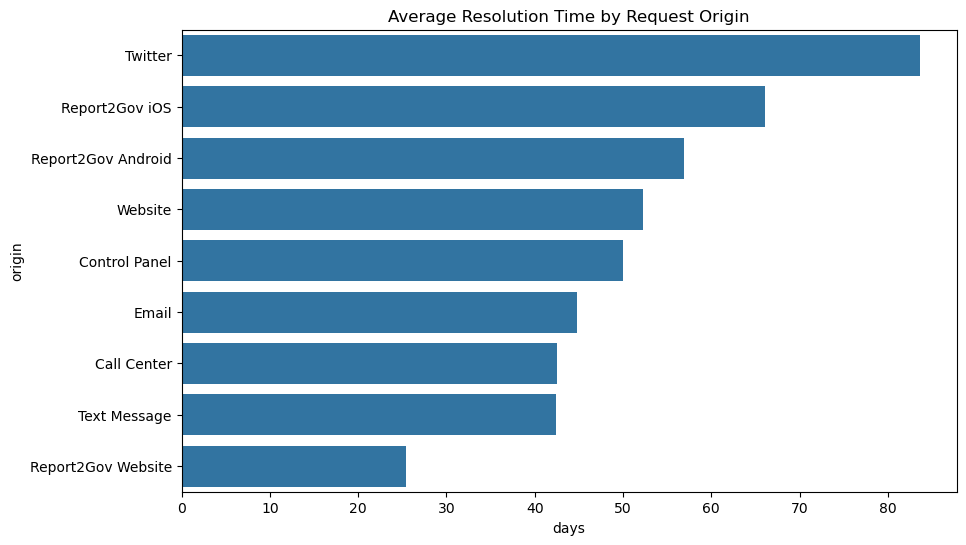

In [81]:
import seaborn as sns
plt.figure(figsize=(10,6))
sns.barplot(x='avg_time', y='origin', data=origin_analysis.reset_index())
plt.title("Average Resolution Time by Request Origin")
plt.xlabel("days")
plt.show()

In [78]:
closed_requests['requests_per_1k'] = (
    closed_requests.groupby('neighborhood')['num_requests'].transform('count') 
    / closed_requests['2020_Total_Population'] 
    * 1000
)
sns.lmplot(x='requests_per_1k', y='time_taken', data=closed_requests)

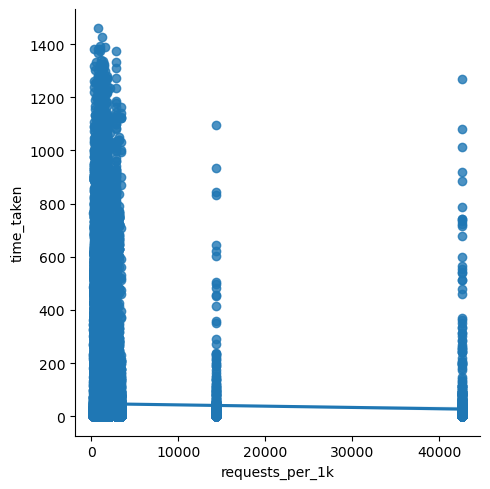

In [79]:
plt.show()